# Module 6 - Shape Detector
# Contours, Area Filtering, and Annotation

In [2]:
!git clone https://github.com/catyobi/cv2.git

Cloning into 'cv2'...
remote: Enumerating objects: 439, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 439 (delta 70), reused 21 (delta 21), pack-reused 322 (from 1)
Receiving objects: 100% (439/439), 182.05 MiB | 29.13 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Updating files: 100% (267/267), done.


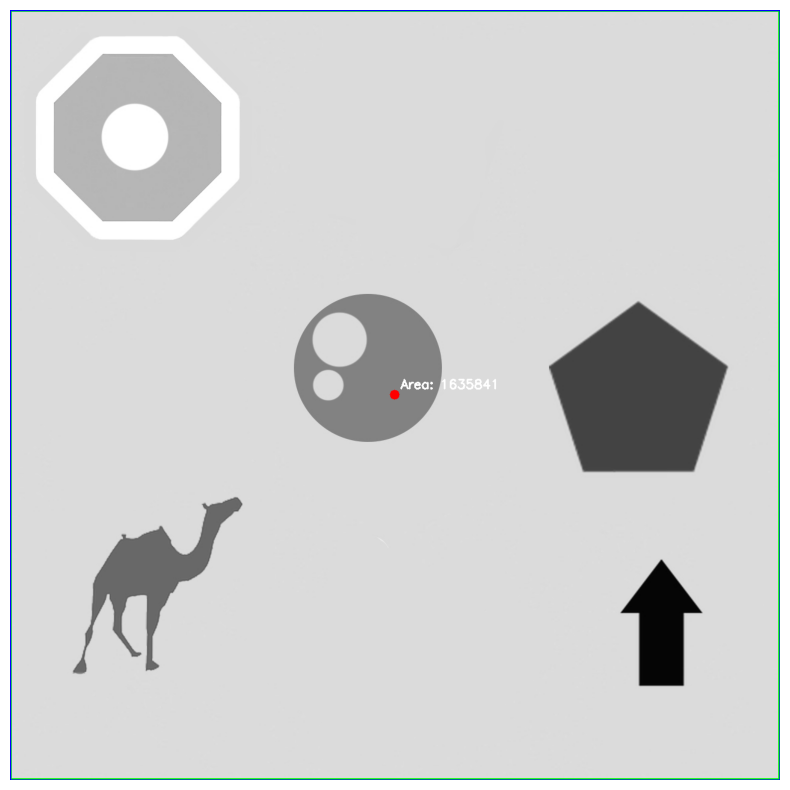

Number of large shapes found: 1


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load, convert to grayscale, threshold.
img = cv2.imread('cv2/module05-contours/shapes.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Step 2: Find EXTERNAL contours.
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 3: Create a copy of the original image to draw on.
imageCopy = img.copy()

count = 0

# Step 4: Loop through contours.
for cnt in contours:
    # a) Compute contour area
    area = cv2.contourArea(cnt)

    # b) If area > 10000
    if area > 10000:
        count += 1

        # Draw contour in green
        cv2.drawContours(imageCopy, [cnt], -1, (0, 255, 0), 3)

        # Upright bounding box in blue
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(imageCopy, (x, y), (x + w, y + h), (255, 0, 0), 2)

        # Centroid using moments
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])

            # Draw centroid in red
            cv2.circle(imageCopy, (cX, cY), 8, (0, 0, 255), -1)

            # Label the area near centroid
            cv2.putText(imageCopy,
                        f'Area: {int(area)}',
                        (cX + 10, cY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (255, 255, 255),
                        2)

# Step 5: Display the result.
plt.figure(figsize=(10,10))
plt.imshow(imageCopy[:, :, ::-1])
plt.axis('off')
plt.show()

# Step 6: Print the count.
print("Number of large shapes found:", count)